# IS6052: Predictive Analytics Assignment (Individual Project)

# Importing essential libraries for data processing, analysis, and visualization.

In [108]:
# Importing essential libraries for data processing and analysis.
import numpy as np
import pandas as pd
 
# Visualization libraries.
import matplotlib.pyplot as plt
import seaborn as sns

# Importing Dataset.

In [109]:
# Loading the dataset.
file_path = "D:\\Masters Study Abroad\\Notes from Canvas\\IS6052 Predictive Analytics\\Individual Project\\Ireland House Price Final.csv"
hp_df = pd.read_csv(file_path)
 
# Displaying the first few rows to verify it's loaded correctly.
hp_df.head()

,ID,property_scope,availability,location,size,total_sqft,bath,balcony,buying or not buying,BER,Renovation needed,price-per-sqft-$
0,0,Extended Coverage,17-Oct,Fingal,2 BED,1056,2.0,1.0,No,A,No,419.928030
1,1,Land Parcel,Ready To Move,South Dublin,4 Bedroom,2600,5.0,3.0,No,D,Yes,523.846154
2,2,Constructed Space,Ready To Move,Dun Laoghaire,3 BED,1440,2.0,3.0,No,G,Yes,488.680556
3,3,Extended Coverage,Ready To Move,South Dublin,3 BED,1521,3.0,1.0,No,G,Yes,708.908613
4,4,Extended Coverage,Ready To Move,DCC,2 BED,1200,2.0,1.0,No,F,Yes,482.375000


# Dataset Structure and Basic Information.

In [110]:
# Displaying the basic info of the dataset.
print("Information of the Dataset")
hp_df.info()

Information of the Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    13320 non-null  int64  
 1   property_scope        13320 non-null  object 
 2   availability          13320 non-null  object 
 3   location              13319 non-null  object 
 4   size                  13304 non-null  object 
 5   total_sqft            13320 non-null  object 
 6   bath                  13247 non-null  float64
 7   balcony               12711 non-null  float64
 8   buying or not buying  13320 non-null  object 
 9   BER                   13320 non-null  object 
 10  Renovation needed     13320 non-null  object 
 11  price-per-sqft-$      13074 non-null  float64
dtypes: float64(3), int64(1), object(8)
memory usage: 1.2+ MB


# Checking for missing values in each column.

In [111]:
# Checking for missing values in each column.
missing_values = hp_df.isnull().sum()
missing_values[missing_values > 0]

location              1
size                 16
bath                 73
balcony             609
price-per-sqft-$    246
dtype: int64

# Descriptive Statistics.

In [112]:
#Generating descriptive statistics for the numerical columns.
hp_df.describe()

,ID,bath,balcony,price-per-sqft-$
count,13320.000000,13247.000000,12711.000000,1.307400e+04
mean,6659.500000,2.692610,1.584376,1.427913e+03
std,3845.297128,1.341458,0.817263,4.611435e+04
min,0.000000,1.000000,0.000000,3.039868e+01
25%,3329.750000,2.000000,1.000000,4.841873e+02
50%,6659.500000,2.000000,2.000000,6.190909e+02
75%,9989.250000,3.000000,2.000000,8.338172e+02
max,13319.000000,40.000000,3.000000,4.953333e+06


# Modifying column names for easier access.

In [113]:
#Renaming the column names.
hp_df.rename(columns={
    'size': 'bhk',
    'bath': 'bathrooms',
    'buying or not buying': 'buying_status',
    'BER': 'energy_rating',
    'Renovation needed': 'renovation_needed',
    'price-per-sqft-$': 'price_per_sqft'
}, inplace=True)

#Verifing the new column names.
hp_df.columns

Index(['ID', 'property_scope', 'availability', 'location', 'bhk', 'total_sqft',
       'bathrooms', 'balcony', 'buying_status', 'energy_rating',
       'renovation_needed', 'price_per_sqft'],
      dtype='object')

# Analyzing unique values in each column to understand data variability.

In [114]:
#Displaying the number of unique values and examples for each column to understand data variability.
for column in hp_df.columns:
    unique_values = hp_df[column].unique()
    num_unique = len(unique_values)
    print(f"Column '{column}' has {num_unique} unique values.\nExample: {unique_values[:5]}\n")

Column 'ID' has 13320 unique values.
Example: [0 1 2 3 4]

Column 'property_scope' has 4 unique values.
Example: ['Extended Coverage' 'Land Parcel' 'Constructed Space' 'Usable Interior']

Column 'availability' has 81 unique values.
Example: ['17-Oct' 'Ready To Move' '18-May' '18-Feb' '19-Dec']

Column 'location' has 6 unique values.
Example: ['Fingal' 'South Dublin' 'Dun Laoghaire' 'DCC' 'Other']

Column 'bhk' has 31 unique values.
Example: ['2 BED' '4 Bedroom' '3 BED' '4 BED' '6 Bedroom']

Column 'total_sqft' has 2117 unique values.
Example: ['1056' '2600' '1440' '1521' '1200']

Column 'bathrooms' has 20 unique values.
Example: [2. 5. 3. 4. 6.]

Column 'balcony' has 5 unique values.
Example: [ 1.  3. nan  2.  0.]

Column 'buying_status' has 2 unique values.
Example: ['No' 'Yes']

Column 'energy_rating' has 7 unique values.
Example: ['A' 'D' 'G' 'F' 'C']

Column 'renovation_needed' has 3 unique values.
Example: ['No' 'Yes' 'Maybe']

Column 'price_per_sqft' has 7537 unique values.
Examp

# Initial EDA

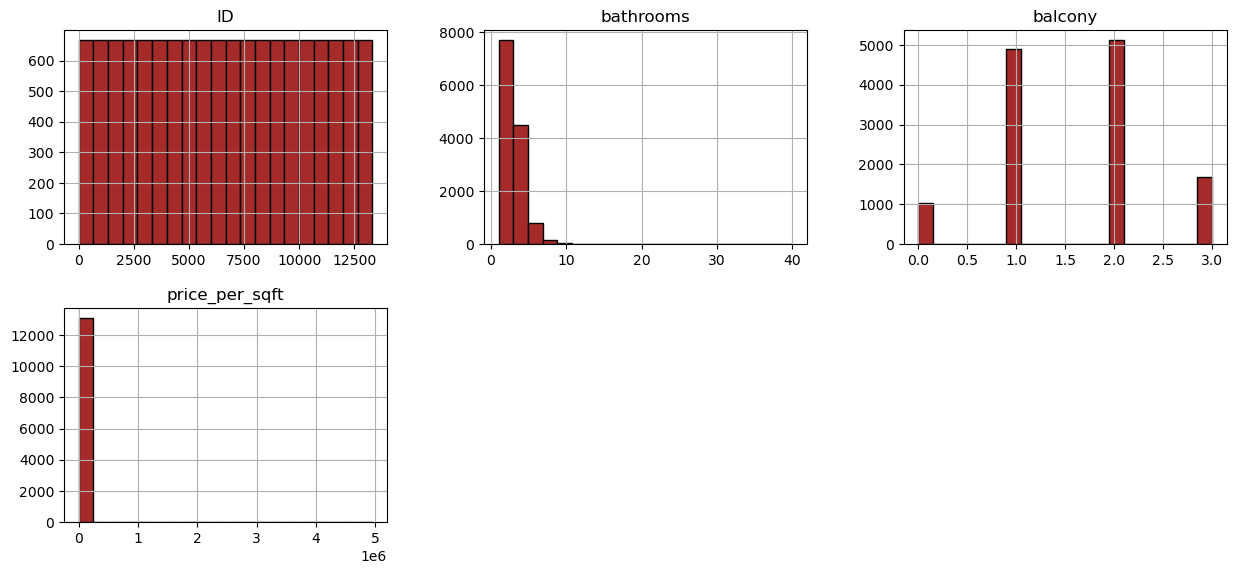

In [115]:
# Ploting histograms for all numerical columns.
hp_df.hist(bins=20, figsize=(15, 10), layout=(3, 3), color='brown', edgecolor='black')
plt.subplots_adjust(hspace=0.3)
plt.show()

# Visualizing the distribution of categorical features using bar plots.

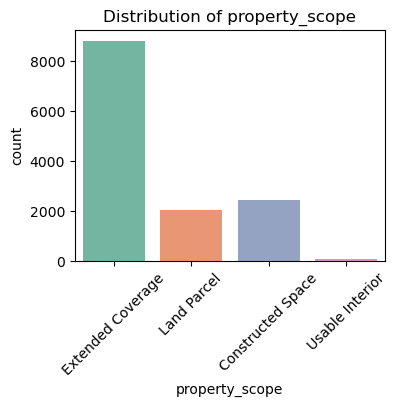

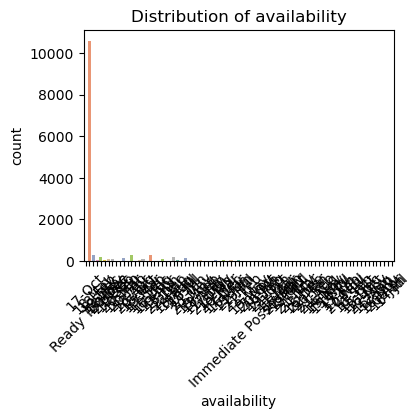

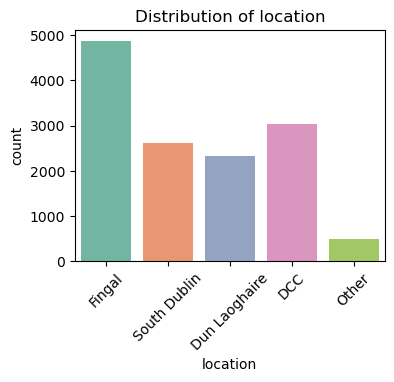

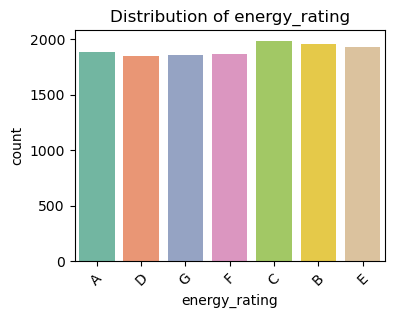

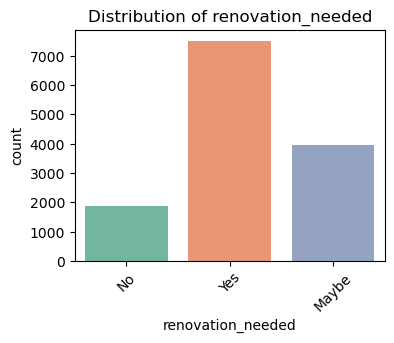

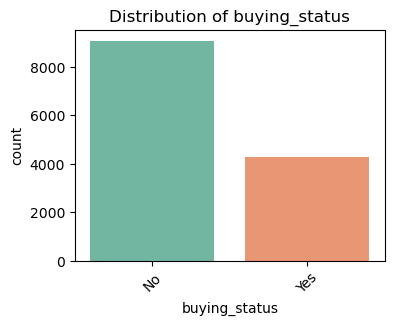

In [116]:
#Creating Bar plots for categorical features.
categorical_columns = ['property_scope', 'availability', 'location', 'energy_rating', 'renovation_needed', 'buying_status']
for col in categorical_columns:
    plt.figure(figsize=(4, 3))
    sns.countplot(x=col, data=hp_df, hue=col, palette='Set2', dodge=False, legend=False)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

# Standardizing and formatting the column values.

In [117]:
# Assuming 'availability' column to the number of days from the current date for analysis in 2025.
today = pd.to_datetime('today')
 
# Function to convert availability to days from the reference date
def convert_availability(availability):
    if availability in ["Immediate Possession", "Ready To Move"]:
        return 0
    try:
        # Parse date assuming it's in 'DD-MMM' format and the year is 2024
        date = pd.to_datetime(f'{availability}-2025', format='%d-%b-%Y')
        delta = (date - today).days
        return max(0, delta)  # Ensure non-negative days value
    except ValueError as e:
        print(f"Error processing date: {availability} with error {e}")
        return None  # Handle any unexpected formats or errors
 
# Applying the conversion to the 'availability' column
hp_df['availability'] = hp_df['availability'].apply(convert_availability)
 
# Converting 'availability' column to the number of days from the current date for analysis in 2025.
hp_df['availability'].head()

0    312
1      0
2      0
3      0
4      0
Name: availability, dtype: int64

In [118]:
hp_df['availability'].unique()

array([312,   0, 160,  71, 375, 344, 376, 377, 284, 285,  99,  73, 130,
       254, 313, 100, 282, 374, 251, 131, 191, 378,  44, 252,  41, 220,
       221, 194, 162, 253, 283, 159, 190, 163,  40, 101, 373,  97, 192,
       195, 222,  74, 161, 343, 315, 193,  72, 316,  43,  98, 129, 164,
       314, 224, 347, 102, 372, 103,  42, 286, 255, 340, 345, 341, 219,
       188,  70, 346, 223, 281, 310, 371, 311, 348, 249,  39, 342, 132,
        38, 217], dtype=int64)

**Display unique values in the 'availability' column after conversion.**

In [119]:
hp_df.head()

,ID,property_scope,availability,location,bhk,total_sqft,bathrooms,balcony,buying_status,energy_rating,renovation_needed,price_per_sqft
0,0,Extended Coverage,312,Fingal,2 BED,1056,2.0,1.0,No,A,No,419.928030
1,1,Land Parcel,0,South Dublin,4 Bedroom,2600,5.0,3.0,No,D,Yes,523.846154
2,2,Constructed Space,0,Dun Laoghaire,3 BED,1440,2.0,3.0,No,G,Yes,488.680556
3,3,Extended Coverage,0,South Dublin,3 BED,1521,3.0,1.0,No,G,Yes,708.908613
4,4,Extended Coverage,0,DCC,2 BED,1200,2.0,1.0,No,F,Yes,482.375000


**Extracting and standardizing the 'bhk' column to numerical values for consistency.**

In [120]:
# Standardizing the 'bhk' column to be numerical by extracting the number of bathrooms.
hp_df['bhk'] = hp_df['bhk'].astype(str).str.extract(r'(\d+)')[0].astype('Int64')

#Verification.
hp_df['bhk'].unique()

<IntegerArray>
[2, 4, 3, 6, 1, 8, 7, 5, 11, 9, <NA>, 27, 10, 19, 16, 43, 14, 12, 13, 18]
Length: 20, dtype: Int64

In [121]:
#Verifying the standardized column.
hp_df.head()

,ID,property_scope,availability,location,bhk,total_sqft,bathrooms,balcony,buying_status,energy_rating,renovation_needed,price_per_sqft
0,0,Extended Coverage,312,Fingal,2,1056,2.0,1.0,No,A,No,419.928030
1,1,Land Parcel,0,South Dublin,4,2600,5.0,3.0,No,D,Yes,523.846154
2,2,Constructed Space,0,Dun Laoghaire,3,1440,2.0,3.0,No,G,Yes,488.680556
3,3,Extended Coverage,0,South Dublin,3,1521,3.0,1.0,No,G,Yes,708.908613
4,4,Extended Coverage,0,DCC,2,1200,2.0,1.0,No,F,Yes,482.375000


**Standardizing 'total_sqft' values to square feet by converting different units and averaging ranges.**

In [122]:
# Converting 'total_sqft' to uniform square feet, averaging ranges and converting various units, updating the column in place.
hp_df['total_sqft'] = hp_df['total_sqft'].apply(lambda sqft: (
    sum(map(float, str(sqft).split('-'))) / 2 if '-' in str(sqft) else
    float(str(sqft).split('Sq.')[0]) * 10.764 if 'Sq. Meter' in str(sqft) else
    float(str(sqft).split('Sq.')[0]) * 9.0 if 'Sq. Yards' in str(sqft) else
    float(str(sqft).split('Acres')[0]) * 43560 if 'Acres' in str(sqft) else
    float(str(sqft).split('Perch')[0]) * 272.25 if 'Perch' in str(sqft) else
    float(str(sqft).split('Guntha')[0]) * 1089 if 'Guntha' in str(sqft) else
    float(str(sqft).split('Grounds')[0]) * 2400 if 'Grounds' in str(sqft) else
    float(sqft) if str(sqft).replace('.', '', 1).isdigit() else
    None
))

#Verification.
hp_df.head()

,ID,property_scope,availability,location,bhk,total_sqft,bathrooms,balcony,buying_status,energy_rating,renovation_needed,price_per_sqft
0,0,Extended Coverage,312,Fingal,2,1056.0,2.0,1.0,No,A,No,419.928030
1,1,Land Parcel,0,South Dublin,4,2600.0,5.0,3.0,No,D,Yes,523.846154
2,2,Constructed Space,0,Dun Laoghaire,3,1440.0,2.0,3.0,No,G,Yes,488.680556
3,3,Extended Coverage,0,South Dublin,3,1521.0,3.0,1.0,No,G,Yes,708.908613
4,4,Extended Coverage,0,DCC,2,1200.0,2.0,1.0,No,F,Yes,482.375000


In [123]:
#Checking for unique values.
hp_df['total_sqft'].unique()

array([1056. , 2600. , 1440. , ..., 1258.5,  774. , 4689. ])

**Converting 'bathrooms' column to integer type and filling NaN values with 0 for consistency.**

In [124]:
# Changing the 'bathrooms' column from float to int, and handling NaN values by filling them with 0
hp_df['bathrooms'] = hp_df['bathrooms'].astype('Int64')
  
# Verifying the changes.
hp_df['bathrooms'].head()
hp_df['total_sqft'].unique()

array([1056. , 2600. , 1440. , ..., 1258.5,  774. , 4689. ])

**Converting the 'balcony' column to integer type and filling NaN values with 0 for data consistency.**

In [125]:
# Converting the 'balcony' column from float to int, and handling NaN values by filling them with 0
hp_df['balcony'] = hp_df['balcony'].astype('Int64')

# Verifying the changes.
hp_df['balcony'].head()


0    1
1    3
2    3
3    1
4    1
Name: balcony, dtype: Int64

**Mapping 'buying_status' column from categorical 'Yes'/'No' values to numerical 0/1 for better analysis.**

In [126]:
# Converting 'buying_status' from 'Yes'/'No' to 0/1
hp_df['buying_status'] = hp_df['buying_status'].map({'Yes': 1, 'No': 0})

#Verifying the 'buying_status' column.
hp_df['buying_status'].head()


0    0
1    0
2    0
3    0
4    0
Name: buying_status, dtype: int64

In [127]:
hp_df.head()

,ID,property_scope,availability,location,bhk,total_sqft,bathrooms,balcony,buying_status,energy_rating,renovation_needed,price_per_sqft
0,0,Extended Coverage,312,Fingal,2,1056.0,2,1,0,A,No,419.928030
1,1,Land Parcel,0,South Dublin,4,2600.0,5,3,0,D,Yes,523.846154
2,2,Constructed Space,0,Dun Laoghaire,3,1440.0,2,3,0,G,Yes,488.680556
3,3,Extended Coverage,0,South Dublin,3,1521.0,3,1,0,G,Yes,708.908613
4,4,Extended Coverage,0,DCC,2,1200.0,2,1,0,F,Yes,482.375000


**Converting 'energy_rating' to integers based on efficiency levels.**

In [128]:
# Mapping enrgy rating from 'energy_rating' ratings to integers
energy_rating_mapping = {
    'A': 1,  # Highest energy efficiency
    'B': 2,
    'C': 3,
    'D': 4,
    'E': 5,
    'F': 6,
    'G': 7   # Lowest energy efficiency
}
 
# Apply the mapping to the 'energy_rating' column
hp_df['energy_rating'] = hp_df['energy_rating'].map(energy_rating_mapping)


In [129]:
#Verifying the energy_rating column.
hp_df['energy_rating'].head()

0    1
1    4
2    7
3    7
4    6
Name: energy_rating, dtype: int64

**Binary encoding 'renovation_needed' column: Mapping 'Yes'/'Maybe' to 1 and 'No' to 0.**

In [130]:
# Binary encoding: 'Yes' and 'Maybe' as 1, 'No' as 0
hp_df['renovation_needed'] = hp_df['renovation_needed'].map({'Yes': 1, 'Maybe': 1, 'No': 0})

hp_df['renovation_needed'].head()

0    0
1    1
2    1
3    1
4    1
Name: renovation_needed, dtype: int64

**Rounding off 'price_per_sqft' values to 2 decimal places for consistency.**

In [131]:
# Rounding the 'price_per_sqft' column to two decimal places
hp_df['price_per_sqft'] = hp_df['price_per_sqft'].round(2)

#Verifying.
hp_df['price_per_sqft'].head()

0    419.93
1    523.85
2    488.68
3    708.91
4    482.38
Name: price_per_sqft, dtype: float64

In [132]:
hp_df.head()

,ID,property_scope,availability,location,bhk,total_sqft,bathrooms,balcony,buying_status,energy_rating,renovation_needed,price_per_sqft
0,0,Extended Coverage,312,Fingal,2,1056.0,2,1,0,1,0,419.93
1,1,Land Parcel,0,South Dublin,4,2600.0,5,3,0,4,1,523.85
2,2,Constructed Space,0,Dun Laoghaire,3,1440.0,2,3,0,7,1,488.68
3,3,Extended Coverage,0,South Dublin,3,1521.0,3,1,0,7,1,708.91
4,4,Extended Coverage,0,DCC,2,1200.0,2,1,0,6,1,482.38


**Checking unique values in the 'availability' column.**

In [133]:
hp_df['availability'].unique()

array([312,   0, 160,  71, 375, 344, 376, 377, 284, 285,  99,  73, 130,
       254, 313, 100, 282, 374, 251, 131, 191, 378,  44, 252,  41, 220,
       221, 194, 162, 253, 283, 159, 190, 163,  40, 101, 373,  97, 192,
       195, 222,  74, 161, 343, 315, 193,  72, 316,  43,  98, 129, 164,
       314, 224, 347, 102, 372, 103,  42, 286, 255, 340, 345, 341, 219,
       188,  70, 346, 223, 281, 310, 371, 311, 348, 249,  39, 342, 132,
        38, 217], dtype=int64)

**Saving the cleaned DataFrame to a CSV file.**

In [134]:
hp_df.to_csv(r"D:\Masters Study Abroad\Notes from Canvas\IS6052 Predictive Analytics\Individual Project\Meghu_Cleaned_Dataset", index=False)

# Generating scatter plots for all numerical columns to visualize data distribution and identify patterns in the dataset

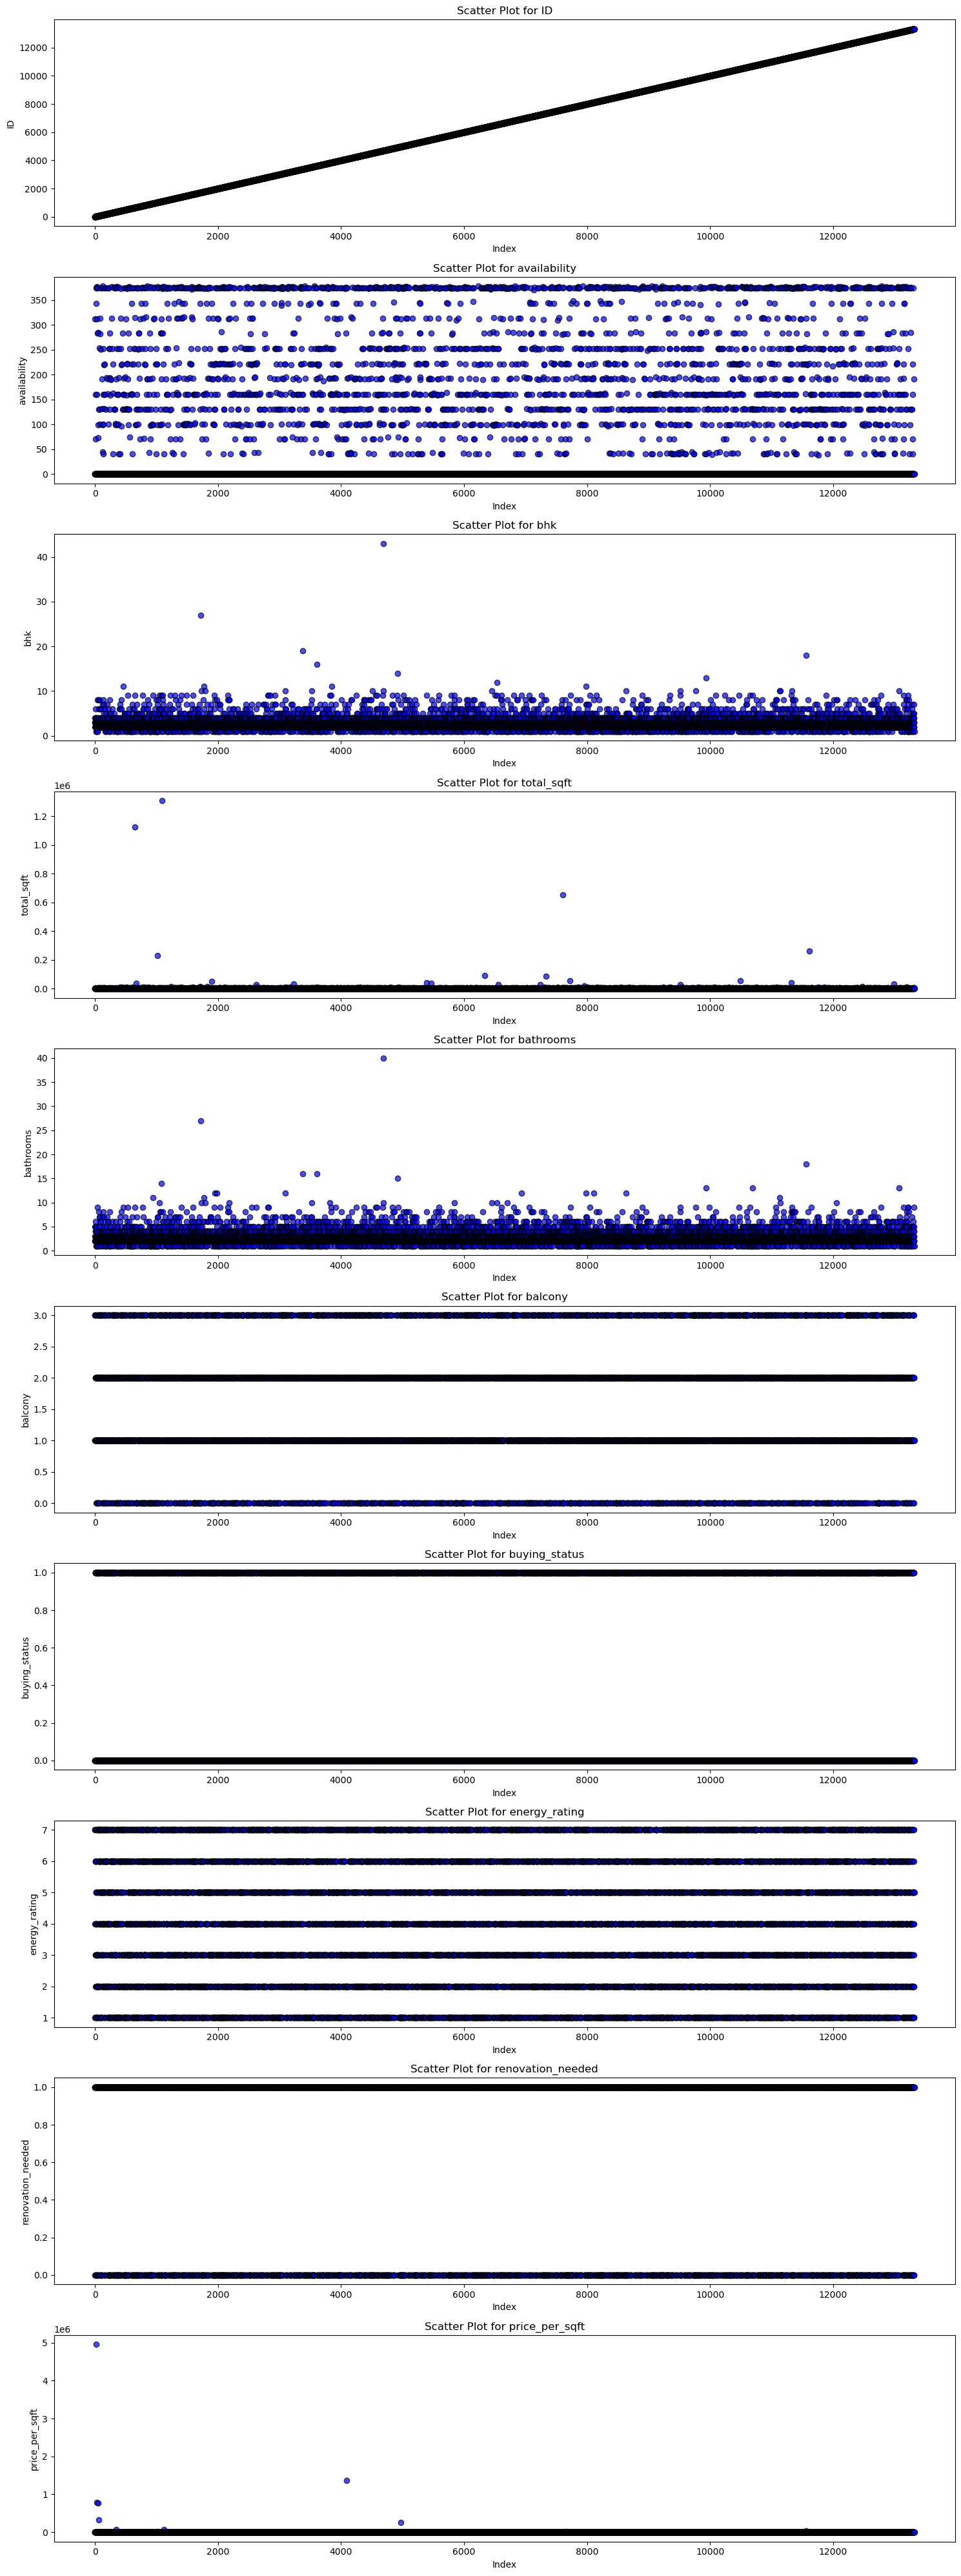

In [135]:
# Looping through all numerical columns in the dataset.
numerical_columns = hp_df.select_dtypes(include=['float64', 'int64']).columns

# Creating scatter plots for each numerical column.
plt.figure(figsize=(15, len(numerical_columns) * 4))

# Looping through each numerical column and create a scatter plot.
for i, column in enumerate(numerical_columns, start=1):
    plt.subplot(len(numerical_columns), 1, i)
    plt.scatter(range(len(hp_df)), hp_df[column], alpha=0.7, color='blue', edgecolor='k')
    plt.title(f"Scatter Plot for {column}")
    plt.xlabel('Index')
    plt.ylabel(column)

# Adjusting the layout to prevent overlapping of plots.
plt.tight_layout()

# Displaying the scatter plots.
plt.show()

# Removing outliers from specified numerical columns using the IQR method to clean the dataset for better analysis.


In [136]:
def remove_outliers_iqr(df, columns):
    """
    Removes outliers from the specified columns of a DataFrame using the IQR method,
    updating the original DataFrame in place.
    
    Parameters:
        df (DataFrame): The input DataFrame to modify.
        columns (list): List of numerical columns to check for outliers.
    
    Returns:
        None: Modifies the input DataFrame in place.
    """
    for column in columns:
        Q1 = df[column].quantile(0.25)  # First quartile (25th percentile)
        Q3 = df[column].quantile(0.75)  # Third quartile (75th percentile)
        IQR = Q3 - Q1  # Interquartile range
        lower_bound = Q1 - 1.5 * IQR  # Lower bound for outliers
        upper_bound = Q3 + 1.5 * IQR  # Upper bound for outliers
        
        # Keeping only rows within the bounds
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    
    # Updating the original DataFrame in place
    hp_df.drop(hp_df.index.difference(df.index), inplace=True)

# Specifying the columns for which you want to remove outliers
columns_to_clean = ['bhk', 'total_sqft', 'bathrooms', 'price_per_sqft']

# Removing outliers from the specified columns
remove_outliers_iqr(hp_df, columns_to_clean)

# Displaying the updated dataset shape
print(f"Updated dataset shape after removing outliers: {hp_df.shape}")

Updated dataset shape after removing outliers: (10320, 12)


# Visualizing numerical columns with scatter plots to observe patterns and outliers.

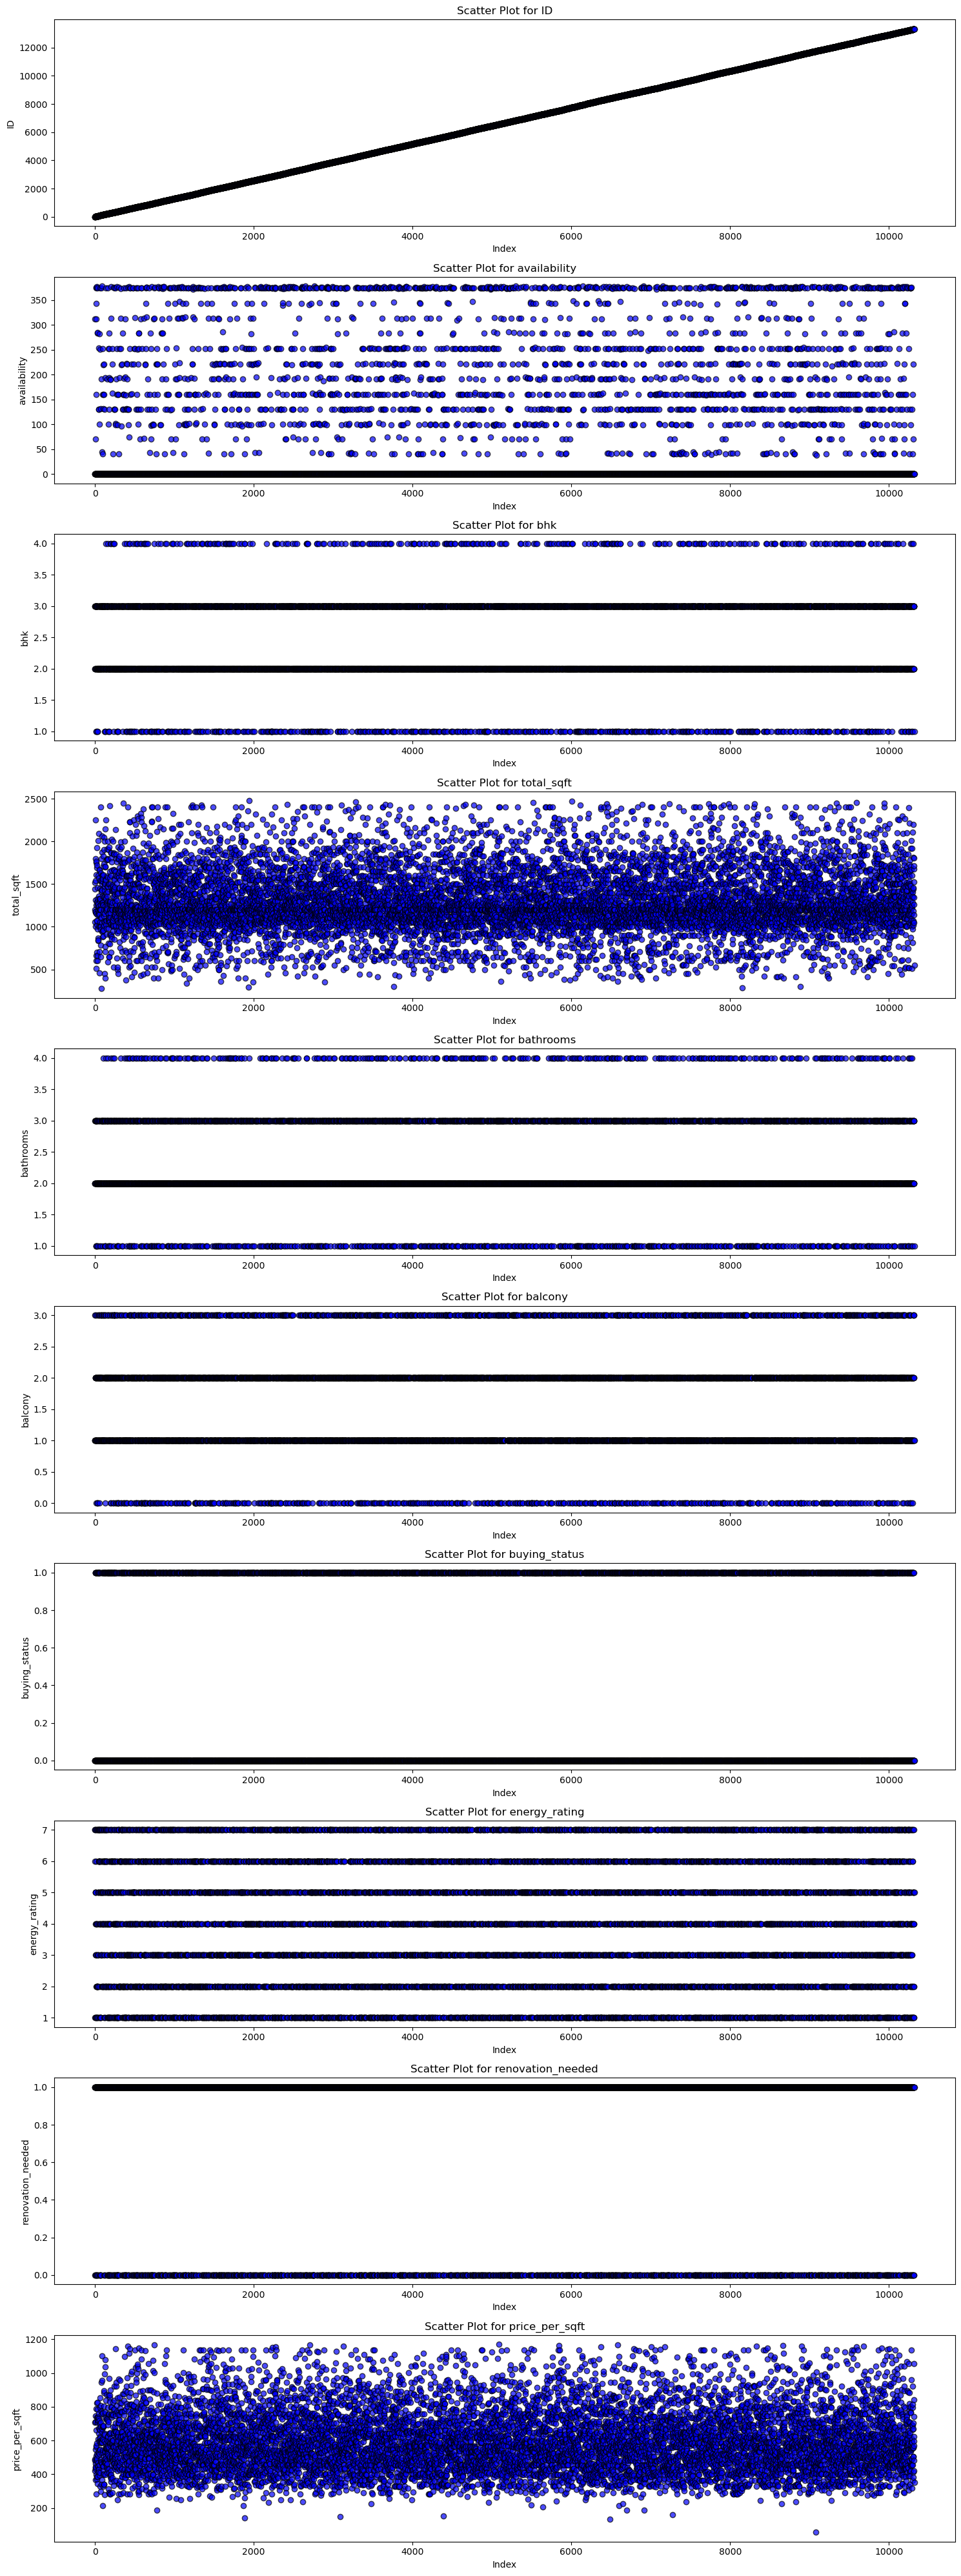

In [137]:
# Creating scatter plots for each numerical column
plt.figure(figsize=(15, len(numerical_columns) * 4))

for i, column in enumerate(numerical_columns, start=1):
    plt.subplot(len(numerical_columns), 1, i)
    plt.scatter(range(len(hp_df)), hp_df[column], alpha=0.7, color='blue', edgecolor='k')
    plt.title(f"Scatter Plot for {column}")
    plt.xlabel('Index')
    plt.ylabel(column)

plt.tight_layout()
plt.show()


**Removing the 'ID' column from the dataset to ensure it does not interfere with analysis or modeling.**

In [138]:
# Dropping the 'ID' column from the DataFrame
hp_df = hp_df.drop('ID', axis=1)

In [139]:
hp_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10320 entries, 0 to 13319
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   property_scope     10320 non-null  object 
 1   availability       10320 non-null  int64  
 2   location           10319 non-null  object 
 3   bhk                10320 non-null  Int64  
 4   total_sqft         10320 non-null  float64
 5   bathrooms          10320 non-null  Int64  
 6   balcony            10138 non-null  Int64  
 7   buying_status      10320 non-null  int64  
 8   energy_rating      10320 non-null  int64  
 9   renovation_needed  10320 non-null  int64  
 10  price_per_sqft     10320 non-null  float64
dtypes: Int64(3), float64(2), int64(4), object(2)
memory usage: 997.7+ KB


# Checking and displaying columns with missing values.

In [140]:
# Checking for null values in the dataset
null_counts = hp_df.isnull().sum()

# Displaying the columns with missing values
print("Columns with missing values:\n")
print(null_counts[null_counts > 0])

Columns with missing values:

location      1
balcony     182
dtype: int64


# Handling missing data in the DataFrame.

In [141]:
# Replace missing values in 'location' with 'Other'
hp_df['location'] = hp_df['location'].fillna('Other')

In [142]:
# Replacing missing values in 'balcony' with the mean of the column
hp_df['balcony'] = hp_df['balcony'].astype(float)
hp_df['balcony'] = hp_df['balcony'].fillna(hp_df['balcony'].mean())

In [143]:
# Displaying columns with missing values
print("Columns with missing values:\n")
print(null_counts[null_counts > 0])

Columns with missing values:

location      1
balcony     182
dtype: int64


# Displaying a summary of missing values after handling them.

In [144]:
# Displaying confirmation of missing values handled
print("Missing values after handling:\n")
print(hp_df.isnull().sum())

Missing values after handling:

property_scope       0
availability         0
location             0
bhk                  0
total_sqft           0
bathrooms            0
balcony              0
buying_status        0
energy_rating        0
renovation_needed    0
price_per_sqft       0
dtype: int64


In [145]:
hp_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10320 entries, 0 to 13319
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   property_scope     10320 non-null  object 
 1   availability       10320 non-null  int64  
 2   location           10320 non-null  object 
 3   bhk                10320 non-null  Int64  
 4   total_sqft         10320 non-null  float64
 5   bathrooms          10320 non-null  Int64  
 6   balcony            10320 non-null  float64
 7   buying_status      10320 non-null  int64  
 8   energy_rating      10320 non-null  int64  
 9   renovation_needed  10320 non-null  int64  
 10  price_per_sqft     10320 non-null  float64
dtypes: Int64(2), float64(3), int64(4), object(2)
memory usage: 987.7+ KB


# Feature Engineering

# Ratio of Bathrooms to Bedrooms

In [146]:
# Creating a new column 'bath_to_bed_ratio' that calculates the ratio of the number of bathrooms to the number of bedrooms(bhk).
hp_df['bath_to_bed_ratio'] = hp_df['bathrooms'] / hp_df['bhk']

In [147]:
# Display the first 5 rows of the 'bath_to_bed_ratio' column to review the calculated values.
hp_df['bath_to_bed_ratio'].head()

0         1.0
2    0.666667
3         1.0
4         1.0
5         1.0
Name: bath_to_bed_ratio, dtype: Float64

# Total Area to Bedrooms Ratio

In [148]:
# Calculate the ratio of total square footage to bedrooms (bhk) and create a new column
hp_df['area_to_bhk_ratio'] = hp_df['total_sqft'] / hp_df['bhk']

In [149]:
hp_df['area_to_bhk_ratio'].head()

0    528.0
2    480.0
3    507.0
4    600.0
5    585.0
Name: area_to_bhk_ratio, dtype: Float64

# Total Price of the Property

In [150]:
# Calculate the total price of each property based on its square footage and price per square foot
hp_df['Total_Price'] = hp_df['total_sqft'] * hp_df['price_per_sqft']

In [151]:
hp_df['Total_Price'].head()

0     443446.08
2     703699.20
3    1078252.11
4     578856.00
5     431297.10
Name: Total_Price, dtype: float64

# Regression Techniques for Predicting Buying Status

**Logistic Regression**

In [152]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Assume 'hp_df' is your DataFrame containing the dataset

# One-hot encoding categorical variables
hp_df_encoded = pd.get_dummies(hp_df, columns=['property_scope', 'location'])

# Splitting the dataset into training and testing sets
X = hp_df_encoded.drop('buying_status', axis=1)  # Features
y = hp_df_encoded['buying_status']  # Target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Creating and training the logistic regression model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Predicting the Test set results
y_pred = model.predict(X_test_scaled)

# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Output results
print(f'Accuracy: {accuracy*100:.2f}%')
print('Confusion Matrix:\n', conf_matrix)
print('Classification Report:\n', class_report)

Accuracy: 71.56%
Confusion Matrix:
 [[1368   30]
 [ 557  109]]
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.98      0.82      1398
           1       0.78      0.16      0.27       666

    accuracy                           0.72      2064
   macro avg       0.75      0.57      0.55      2064
weighted avg       0.73      0.72      0.65      2064



**Random Forest**

In [153]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Creating and training the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predicting the Test set results
rf_pred = rf_model.predict(X_test)

# Evaluating the model
accuracy = accuracy_score(y_test, rf_pred)
conf_matrix = confusion_matrix(y_test, rf_pred)
class_report = classification_report(y_test, rf_pred)

# Output results
print(f'Accuracy: {accuracy*100:.2f}%')
print('Confusion Matrix:\n', conf_matrix)
print('Classification Report:\n', class_report)

Accuracy: 72.38%
Confusion Matrix:
 [[1295  103]
 [ 467  199]]
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.93      0.82      1398
           1       0.66      0.30      0.41       666

    accuracy                           0.72      2064
   macro avg       0.70      0.61      0.62      2064
weighted avg       0.71      0.72      0.69      2064



**K Nearest Neighbors**

In [154]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Scaling the features and converting back to DataFrame for consistency
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Creating and training the KNN classifier
# You can adjust the number of neighbors; here we use n_neighbors=5 as a common default
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Predicting the Test set results
knn_pred = knn_model.predict(X_test_scaled)

# Evaluating the model
accuracy = accuracy_score(y_test, knn_pred)
conf_matrix = confusion_matrix(y_test, knn_pred)
class_report = classification_report(y_test, knn_pred)

# Output results
print(f'Accuracy: {accuracy*100:.2f}%')
print('Confusion Matrix:\n', conf_matrix)
print('Classification Report:\n', class_report)

Accuracy: 67.83%
Confusion Matrix:
 [[1192  206]
 [ 458  208]]
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.85      0.78      1398
           1       0.50      0.31      0.39       666

    accuracy                           0.68      2064
   macro avg       0.61      0.58      0.58      2064
weighted avg       0.65      0.68      0.65      2064



**Decision Tree**

In [155]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Creating and training the Decision Tree classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predicting the Test set results
dt_pred = dt_model.predict(X_test)

# Evaluating the model
accuracy = accuracy_score(y_test, dt_pred)
conf_matrix = confusion_matrix(y_test, dt_pred)
class_report = classification_report(y_test, dt_pred)

# Output results
print(f'Accuracy: {accuracy*100:.2f}%')
print('Confusion Matrix:\n', conf_matrix)
print('Classification Report:\n', class_report)

Accuracy: 64.24%
Confusion Matrix:
 [[1022  376]
 [ 362  304]]
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.73      0.73      1398
           1       0.45      0.46      0.45       666

    accuracy                           0.64      2064
   macro avg       0.59      0.59      0.59      2064
weighted avg       0.64      0.64      0.64      2064



#  Plotting ROC Curves for all & Calculating the AUC

C:\Users\shamg\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\shamg\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


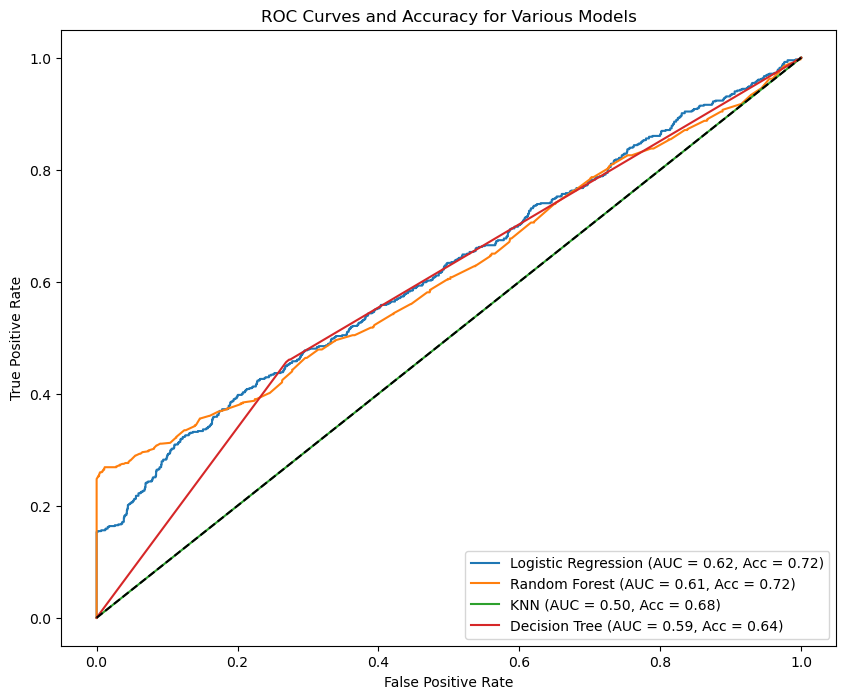

In [156]:
# Calculate probabilities for ROC curves
prob_lr = model.predict_proba(X_test_scaled)[:, 1]
prob_rf = rf_model.predict_proba(X_test)[:, 1]
prob_knn = knn_model.predict_proba(X_test)[:, 1]
prob_dt = dt_model.predict_proba(X_test)[:, 1]

# Calculate ROC and AUC for each model
fpr_lr, tpr_lr, _ = roc_curve(y_test, prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)
accuracy_lr = accuracy_score(y_test, model.predict(X_test_scaled))

fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)
accuracy_rf = accuracy_score(y_test, rf_model.predict(X_test))

fpr_knn, tpr_knn, _ = roc_curve(y_test, prob_knn)
auc_knn = auc(fpr_knn, tpr_knn)
accuracy_knn = accuracy_score(y_test, knn_model.predict(X_test))

fpr_dt, tpr_dt, _ = roc_curve(y_test, prob_dt)
auc_dt = auc(fpr_dt, tpr_dt)
accuracy_dt = accuracy_score(y_test, dt_model.predict(X_test))

# Plotting ROC curves with accuracy in the legend
plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f}, Acc = {accuracy_lr:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f}, Acc = {accuracy_rf:.2f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.2f}, Acc = {accuracy_knn:.2f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.2f}, Acc = {accuracy_dt:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Dashed diagonal line

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves and Accuracy for Various Models')
plt.legend(loc='lower right')
plt.show()

# Hyperparameter Tuning

In [157]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

# Defining the parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 150],  # Number of trees in the forest
    'max_depth': [None, 10, 20],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],  # Minimum samples required at a leaf node
    'max_features': ['sqrt', 'log2'],  # Number of features to consider at each split
}

# Creating the RandomizedSearchCV object
rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=50,  # Number of random combinations to try
    cv=3,  # 3-fold cross-validation
    scoring='accuracy',  # Metric to optimize
    verbose=2,
    random_state=42,
    n_jobs=-1  # Use all processors
)

# Fitting the model to the training data
rf_random_search.fit(X_train, y_train)

# Extracting the best parameters and model
best_rf_model = rf_random_search.best_estimator_
print(f"Best Parameters: {rf_random_search.best_params_}")

# Predicting the Test set results with the best model
rf_best_pred = best_rf_model.predict(X_test)

# Evaluating the tuned model
accuracy = accuracy_score(y_test, rf_best_pred)
conf_matrix = confusion_matrix(y_test, rf_best_pred)
class_report = classification_report(y_test, rf_best_pred)

# Output results
print(f'Accuracy after tuning: {accuracy*100:.2f}%')
print('Confusion Matrix:\n', conf_matrix)
print('Classification Report:\n', class_report)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10}
Accuracy after tuning: 75.63%
Confusion Matrix:
 [[1398    0]
 [ 503  163]]
Classification Report:
               precision    recall  f1-score   support

           0       0.74      1.00      0.85      1398
           1       1.00      0.24      0.39       666

    accuracy                           0.76      2064
   macro avg       0.87      0.62      0.62      2064
weighted avg       0.82      0.76      0.70      2064



Top 10 Most Important Features:
                   Feature  Importance
5            energy_rating    0.217536
16  location_Dun Laoghaire    0.144953
6        renovation_needed    0.095523
19   location_South Dublin    0.086035
10             Total_Price    0.068080
9        area_to_bhk_ratio    0.064791
17         location_Fingal    0.063871
7           price_per_sqft    0.063484
2               total_sqft    0.058699
15            location_DCC    0.046047


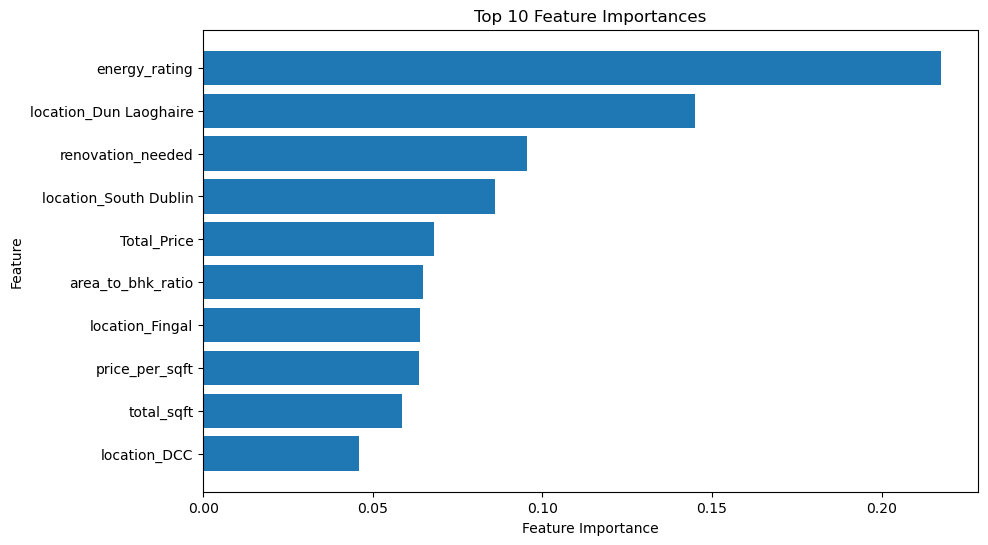

In [158]:
# Fit the best Random Forest model to the training data
best_rf_model.fit(X_train, y_train)

# Get feature importances from the trained model
feature_importances = best_rf_model.feature_importances_

# Create a DataFrame to store feature names and their corresponding importances
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Display the top 10 most important features
print("Top 10 Most Important Features:")
print(feature_importance_df.head(10))

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:10], feature_importance_df['Importance'][:10], align='center')
plt.gca().invert_yaxis()  # Reverse the order for better visualization
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances')
plt.show()